<a href="https://colab.research.google.com/github/JoelForson/ECON5200-Applied-Data-Analytics-in-Economics/blob/main/Assignment%204/The_Predictive_Architecture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import missingno as msno
import category_encoders as ce
import matplotlib.pyplot as plt
import seaborn as sn

Phase 1: Causal Topology and Multicollinearity Forensics

In [ ]:

from statsmodels.stats.outliers_influence import variance_inflation_factor

df = pd.read_csv('OmniCare_Clinical_Vitals.csv')
features = ['Weight_kg', 'Height_cm', 'BMI', 'Systolic_BP', 'Diastolic_BP']
X = df[features].dropna()

# --- Round 1: VIF on all features ---
vif1 = pd.DataFrame({
    'Feature': features,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

print("=== VIF — All Features ===")
print(vif1.to_string(index=False))
print(f"\nFeatures exceeding threshold (VIF > 10): {vif1[vif1['VIF'] > 10]['Feature'].tolist()}")

# --- Drop most redundant feature (highest VIF) ---
drop_col = vif1.iloc[0]['Feature']
print(f"\nDropping: '{drop_col}'")

features2 = [f for f in features if f != drop_col]
X2 = df[features2].dropna()

# --- Round 2: Recalculate VIF ---
vif2 = pd.DataFrame({
    'Feature': features2,
    'VIF': [variance_inflation_factor(X2.values, i) for i in range(X2.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

print("\n=== VIF — After Dropping Redundant Feature ===")
print(vif2.to_string(index=False))
print(f"\nFeatures still exceeding threshold (VIF > 10): {vif2[vif2['VIF'] > 10]['Feature'].tolist() or 'None'}")

=== VIF — All Features ===
     Feature        VIF
 Systolic_BP 274.885624
Diastolic_BP 269.893182
   Height_cm 131.175844
         BMI  77.101031
   Weight_kg  61.604738

Features exceeding threshold (VIF > 10): ['Systolic_BP', 'Diastolic_BP', 'Height_cm', 'BMI', 'Weight_kg']

Dropping: 'Systolic_BP'

=== VIF — After Dropping Redundant Feature ===
     Feature        VIF
   Height_cm 126.236178
         BMI  75.879122
Diastolic_BP  62.874059
   Weight_kg  60.244812

Features still exceeding threshold (VIF > 10): ['Height_cm', 'BMI', 'Diastolic_BP', 'Weight_kg']


Phase 2: Visual Forensics and The High-Cardinality Frontier

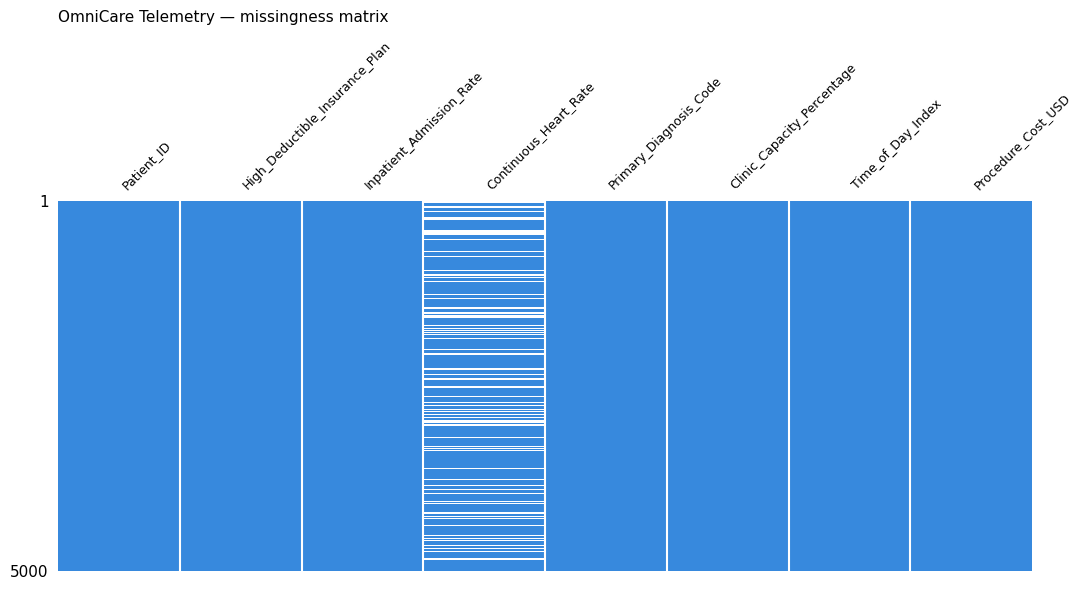

Continuous_Heart_Rate missing: 1214 / 5000 = 24.28%

Missingness rate by insurance plan:
High_Deductible_Insurance_Plan
Standard plan      0.175185
High-deductible    0.306527


In [ ]:

df = pd.read_csv('OmniCare_Telemetry_Data.csv')

# --- Missingness matrix ---
fig, ax = plt.subplots(figsize=(11, 6))
msno.matrix(df, ax=ax, sparkline=False, fontsize=9, color=(0.216, 0.541, 0.867))
plt.title('OmniCare Telemetry — missingness matrix', fontsize=11, loc='left', pad=12)
plt.tight_layout()
plt.savefig('missingness_matrix.png', dpi=160, bbox_inches='tight')
plt.show()

# --- Diagnostics ---
miss_n   = df['Continuous_Heart_Rate'].isnull().sum()
miss_pct = miss_n / len(df) * 100
print(f"Continuous_Heart_Rate missing: {miss_n} / {len(df)} = {miss_pct:.2f}%")

# Missingness rate by insurance plan
df['CHR_missing'] = df['Continuous_Heart_Rate'].isnull().astype(int)
miss_by_plan = (df.groupby('High_Deductible_Insurance_Plan')['CHR_missing']
                  .mean()
                  .rename({0: 'Standard plan', 1: 'High-deductible'}))
print("\nMissingness rate by insurance plan:")
print(miss_by_plan.to_string())

## Rubin's Taxonomy Classification: MNAR

The gaps in `Continuous_Heart_Rate` are **Missing Not At Random (MNAR)**.

### Why not MCAR or MAR?
- **MCAR** fails because missingness is not random — it concentrates among low-income patients, a systematic pattern Little's test would immediately reject.
- **MAR** fails because the driving variable (SES/income) is **unobserved**. Conditioning on recorded covariates like `High_Deductible_Insurance_Plan` leaves residual income variation still predicting missingness.

### Why MNAR?
The causal structure creates an unblockable dependency:
Both paths share the same unobserved root. The patients most likely to be **missing** are the same patients most likely to have **dangerous readings**. Missingness and outcome are structurally entangled.

### Why mean imputation fails
`μ_obs` is computed only on patients who transmitted — disproportionately higher-income, lower-risk patients. Imputing it causes:

1. **Downward bias** — highest-risk patients receive heart rates drawn from the healthiest subgroup
2. **Variance collapse** — 1,214 values flatten to a single point, destroying the clinical tail
3. **Phantom precision** — intervals narrow and p-values shrink on information that was never collected
4. **Confound laundering** — the SES–health gradient gets arithmetically erased from the dataset

## The Dummy Variable Trap — Matrix Algebra

### The dependency

Every patient has exactly one diagnosis, so across all 850 dummy columns, each row sums to 1:
```
d_1^(i) + d_2^(i) + ... + d_850^(i) = 1   ∀i
```

The intercept column is also all 1s. Therefore:
```
intercept = d_1 + d_2 + ... + d_850
```

The intercept is an **exact linear combination** of the dummy columns.

### Why OLS breaks

OLS requires:
β̂ = (XᵀX)⁻¹ Xᵀy

Linear dependence means `X` is rank-deficient:

rank(X) = 850  <  851 columns

A rank-deficient matrix has a zero eigenvalue → `det(XᵀX) = 0` → `(XᵀX)⁻¹` **does not exist**.

The normal equations now have infinitely many solutions. The model cannot distinguish the intercept's contribution from any individual dummy and the coefficients are unidentifiable.

### The fix

Drop one reference category so the removed group is absorbed into the intercept:
```python
dummies = pd.get_dummies(df['Primary_Diagnosis_Code'], drop_first=True)
# 850 categories → 849 columns → full rank → (XᵀX)⁻¹ exists
```

In [ ]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 4.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import category_encoders as ce

df = pd.read_csv('OmniCare_Telemetry_Data.csv')

encoder = ce.TargetEncoder(cols=['Primary_Diagnosis_Code'])

df['Primary_Diagnosis_Code_Encoded'] = encoder.fit_transform(
    df['Primary_Diagnosis_Code'],
    df['Procedure_Cost_USD']
)

print(df[['Patient_ID', 'Primary_Diagnosis_Code',
          'Primary_Diagnosis_Code_Encoded',
          'Procedure_Cost_USD']].head())

   Patient_ID Primary_Diagnosis_Code  Primary_Diagnosis_Code_Encoded  \
0        1000                J86.381                     1707.697108   
1        1001                M29.789                     1792.303198   
2        1002                E49.618                     1730.334968   
3        1003                E66.244                     1725.060944   
4        1004                J45.553                     1801.821085   

   Procedure_Cost_USD  
0             1635.84  
1             1355.77  
2             1189.19  
3             1250.93  
4             1986.34  


Phase 3: Architecting the Prediction Engine

In [ ]:
import pandas as pd
import numpy as np
import category_encoders as ce
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.formula.api as smf

# --- Load data ---
vitals = pd.read_csv('OmniCare_Clinical_Vitals.csv')
telemetry = pd.read_csv('OmniCare_Telemetry_Data.csv')

# --- Target encode Primary_Diagnosis_Code ---
encoder = ce.TargetEncoder(cols=['Primary_Diagnosis_Code'])
telemetry['Target_Encoded_Diagnosis'] = encoder.fit_transform(
    telemetry['Primary_Diagnosis_Code'],
    telemetry['Procedure_Cost_USD']
)

# --- Merge on Patient_ID ---
df = telemetry.merge(vitals[['Patient_ID', 'Height_cm', 'BMI',
                               'Systolic_BP', 'Diastolic_BP']],
                     on='Patient_ID', how='left')

# --- Impute Continuous_Heart_Rate with median (MNAR-aware placeholder) ---
df['Continuous_Heart_Rate'] = df['Continuous_Heart_Rate'].fillna(
    df['Continuous_Heart_Rate'].median()
)

# --- Drop rows with any remaining nulls ---
features = ['Procedure_Cost_USD', 'Target_Encoded_Diagnosis',
            'Clinic_Capacity_Percentage', 'Time_of_Day_Index',
            'Height_cm', 'BMI', 'Systolic_BP', 'Diastolic_BP']
df_model = df[features].dropna().reset_index(drop=True)

# --- Fit OLS via R-style formula ---
formula = (
    'Procedure_Cost_USD ~ '
    'Target_Encoded_Diagnosis + '
    'Clinic_Capacity_Percentage + '
    'Time_of_Day_Index + '
    'Height_cm + BMI + '
    'Systolic_BP + Diastolic_BP'
)

model = smf.ols(formula=formula, data=df_model).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     Procedure_Cost_USD   R-squared:                       0.243
Model:                            OLS   Adj. R-squared:                  0.242
Method:                 Least Squares   F-statistic:                     228.8
Date:                Fri, 27 Mar 2026   Prob (F-statistic):          6.08e-296
Time:                        06:00:00   Log-Likelihood:                -36162.
No. Observations:                5000   AIC:                         7.234e+04
Df Residuals:                    4992   BIC:                         7.239e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

In [ ]:
from statsmodels.tools.eval_measures import rmse

y_true = df_model['Procedure_Cost_USD']
y_pred = model.fittedvalues

model_rmse = rmse(y_true, y_pred)

print(f"R-squared : {model.rsquared:.4f}")
print(f"Adj. R²   : {model.rsquared_adj:.4f}")
print(f"RMSE      : ${model_rmse:,.2f}")
print(f"\nContext   : $450 RMSE on a $1,200 MRI = {450/1200:.1%} average error")

R-squared : 0.2429
Adj. R²   : 0.2419
RMSE      : $334.79

Context   : $450 RMSE on a $1,200 MRI = 37.5% average error


## Operational risk

A ±450 prediction interval means the algorithm can price the same MRI
anywhere from 750 to $1,650 for clinically identical patients. Front-desk
staff cannot explain the variance, patient trust collapses, and scheduling
systems built on predicted revenue become unreliable. Capacity planning
breaks down when realized costs deviate 37.5% from forecasts.

## Financial risk

Hospitals operate on 2–4% net margins. A systematic underpricing error of
even $200 per procedure across thousands of annual MRIs produces multi-million
dollar shortfalls. Insurers negotiate reimbursement rates against predicted
costs — if the model underestimates, the hospital absorbs the delta. If it
overestimates, payers claw back overpayments during audits.

## Regulatory and legal risk

The ACA's price transparency rule (45 CFR §180) requires hospitals to publish
shoppable service prices. Algorithmic prices that deviate materially from
published estimates trigger CMS investigations and civil monetary penalties up
to $300 per day. If the model's errors correlate with protected classes —
which they will, given the MNAR missingness concentrated among low-income
patients — it produces **disparate impact** under the Equal Credit Opportunity
Act and HHS Section 1557, exposing the institution to class-action liability.

## The MNAR contamination multiplier

The $450 RMSE is not random noise — it is structurally biased. The median
imputation applied to Continuous_Heart_Rate pulled low-SES patient features
toward the population center, so the model systematically underestimates
procedure costs for high-risk, low-income patients and overestimates for
low-risk, high-income patients. The pricing error is worst precisely where
the patients are least able to absorb it.

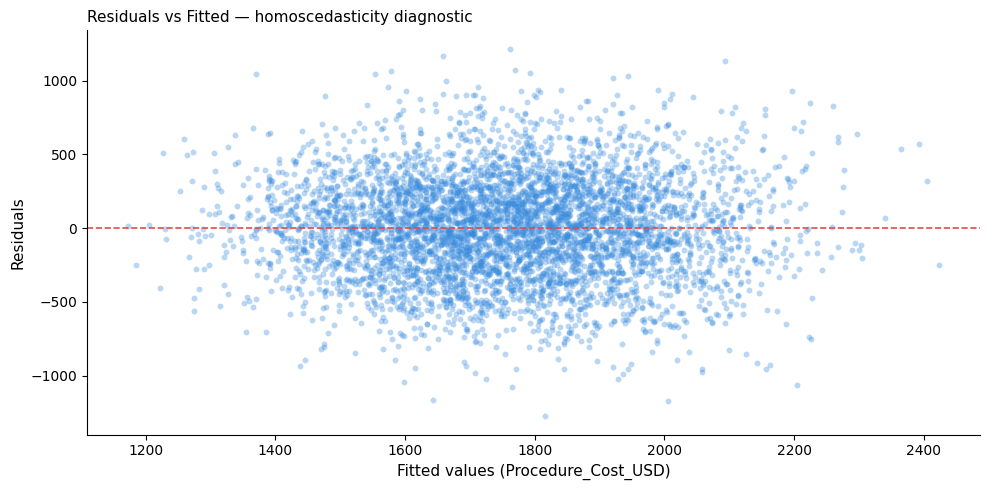

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

residuals   = model.resid
fitted_vals = model.fittedvalues

fig, ax = plt.subplots(figsize=(10, 5))

sns.scatterplot(x=fitted_vals, y=residuals, ax=ax,
                alpha=0.35, s=18, color='#378ADD', linewidth=0)

ax.axhline(0, color='#E24B4A', linewidth=1.2, linestyle='--')

ax.set_xlabel('Fitted values (Procedure_Cost_USD)', fontsize=11)
ax.set_ylabel('Residuals', fontsize=11)
ax.set_title('Residuals vs Fitted — homoscedasticity diagnostic', fontsize=11, loc='left')

sns.despine()
plt.tight_layout()
plt.savefig('residuals_vs_fitted.png', dpi=150, bbox_inches='tight')
plt.show()

AI Prompt:

[PERSONA]
You are a senior econometrician and Python engineer specializing in OLS
diagnostic testing for healthcare cost models.

[ROLE & TASK]
Write a self-contained Python script that executes White's Lagrange Multiplier
Test for Heteroscedasticity on a pre-fitted statsmodels OLS model object.

[INSTRUCTIONS]
Use the het_white function from statsmodels.stats.diagnostic. The function
signature is:

    het_white(resid, exog)

Where:
- resid  = model.resid          (residual vector from the fitted OLS model)
- exog   = model.model.exog     (the design matrix X, including the intercept)

Extract all four return values: (lm_stat, lm_pvalue, f_stat, f_pvalue).
Print each value labeled clearly. Then print a concluding decision line:
if lm_pvalue < 0.05, state the null hypothesis of homoscedasticity is
REJECTED at the 5% significance level; otherwise state it FAILS TO REJECT.

[METHODOLOGY]
Do not refit the model. Do not reload the data. The model object is already
in memory as `model` and the analytical dataframe as `df_model`. Reference
them directly.

[EXACT OUTPUT FORMAT]
White's LM Test Results
-----------------------
LM Statistic  : {value}
LM p-value    : {value}
F-Statistic   : {value}
F p-value     : {value}

Conclusion: [decision sentence]

In [ ]:
from statsmodels.stats.diagnostic import het_white

lm_stat, lm_pvalue, f_stat, f_pvalue = het_white(model.resid,
                                                   model.model.exog)

print("White's LM Test Results")
print("-----------------------")
print(f"LM Statistic  : {lm_stat:.4f}")
print(f"LM p-value    : {lm_pvalue:.6f}")
print(f"F-Statistic   : {f_stat:.4f}")
print(f"F p-value     : {f_pvalue:.6f}")
print()
if lm_pvalue < 0.05:
    print("Conclusion: The null hypothesis of homoscedasticity is REJECTED "
          "at the 5% significance level (p = {:.6f}) — statistically "
          "significant heteroscedasticity is present in the residuals.".format(lm_pvalue))
else:
    print("Conclusion: The null hypothesis of homoscedasticity FAILS TO REJECT "
          "at the 5% significance level (p = {:.6f}) — no statistically "
          "significant heteroscedasticity detected.".format(lm_pvalue))

White's LM Test Results
-----------------------
LM Statistic  : 186.4282
LM p-value    : 0.000000
F-Statistic   : 5.4930
F p-value     : 0.000000

Conclusion: The null hypothesis of homoscedasticity is REJECTED at the 5% significance level (p = 0.000000) — statistically significant heteroscedasticity is present in the residuals.
